In [1]:
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from aedat_dataset import AEDATRespirationDataset
from models.dvRespNet import EventRespirationNet

In [2]:
DATA_DIR = "../data/042025"
CSV_PATH = "../data/ground_truth.csv"
CHECKPOINT_PATH = "cpks/best_model-epoch=79-val_loss=0.42.ckpt"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 1

In [3]:
# --- Load Dataset ---
dataset = AEDATRespirationDataset(            
            data_dir=DATA_DIR,
            csv_path=CSV_PATH,
            sensor_size=(640,480,2),
            filtered=False,
            frames_per_sample=100,
            max_time=10,
            )
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)

# --- Load Model ---
model = EventRespirationNet.load_from_checkpoint(CHECKPOINT_PATH)
model = model.to(DEVICE)
model.eval()

EventRespirationNet(
  (encoder): Sequential(
    (0): Conv2Plus1D(
      (conv_t): Sequential(
        (0): Conv3d(2, 8, kernel_size=(10, 1, 1), stride=(1, 1, 1), bias=False)
        (1): Sequential(
          (0): GroupNorm(4, 8, eps=1e-05, affine=True)
          (1): ReLU()
        )
      )
      (conv_s): Sequential(
        (0): Conv3d(8, 16, kernel_size=(1, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
        (1): Sequential(
          (0): BatchNorm3d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (1): ReLU()
        )
      )
    )
    (1): Conv2Plus1D(
      (conv_t): Sequential(
        (0): Conv3d(16, 16, kernel_size=(10, 1, 1), stride=(1, 1, 1), bias=False)
        (1): Sequential(
          (0): GroupNorm(4, 16, eps=1e-05, affine=True)
          (1): ReLU()
        )
      )
      (conv_s): Sequential(
        (0): Conv3d(16, 32, kernel_size=(1, 3, 3), stride=(1, 2, 2), padding=(1, 1, 1), bias=False)
        (1): Sequential(
     

In [4]:
# --- Evaluation ---
preds = []
targets = []

with torch.no_grad():
    for i, (x, y) in enumerate(dataloader):
        if i >= 100:
            break
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        y_hat = model(x)
        preds.append(y_hat.item())
        targets.append(y.item())


MAE: 0.8337


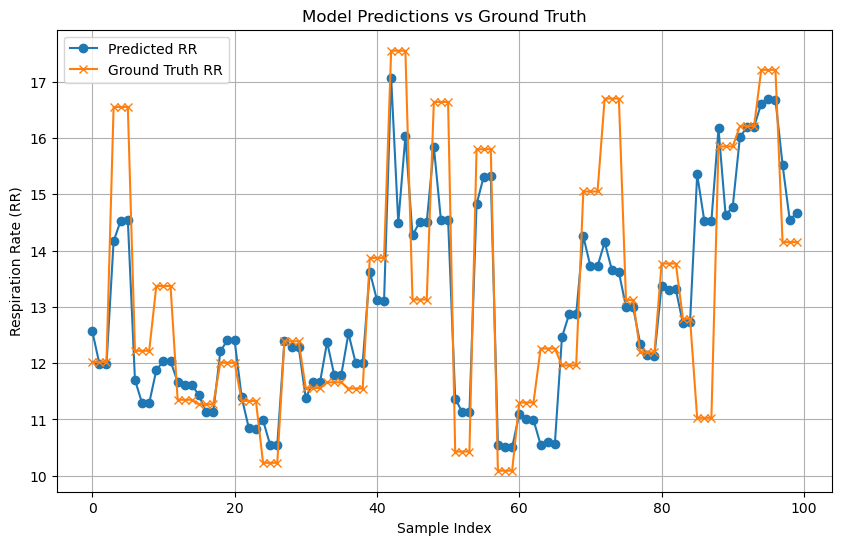

In [5]:
mae = torch.mean(torch.abs(torch.tensor(preds) - torch.tensor(targets)))
print(f"MAE: {mae.item():.4f}")

plt.figure(figsize=(10, 6))
plt.plot(preds, marker='o', label="Predicted RR")
plt.plot(targets, marker='x', label="Ground Truth RR")
plt.xlabel("Sample Index")
plt.ylabel("Respiration Rate (RR)")
plt.title("Model Predictions vs Ground Truth")
plt.legend()
plt.grid(True)
plt.show()
